In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
# pd.read_csv loads the comma-separated files into "DataFrames" (tabular objects)
demo_df = pd.read_excel("Customer_Churn_Data_Large.xlsx")
trans_df = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name= "Transaction_History")
service_df = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name= "Customer_Service")
online_df = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name= "Online_Activity")
churn_df = pd.read_excel("Customer_Churn_Data_Large.xlsx", sheet_name= "Churn_Status")

In [34]:
demo_df.head(2)

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low


In [35]:
trans_df.head(2)

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing


In [37]:
service_df.head(2)

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved


In [36]:
# .groupby('CustomerID') collects all records for one person
# .agg(...) performs math (summing money, counting rows) on those groups
trans_agg = trans_df.groupby('CustomerID').agg(
    TotalSpent=('AmountSpent', 'sum'),       # Total dollars spent by the customer
    TransactionCount=('TransactionID', 'count') # How many times they bought something
).reset_index()

service_agg = service_df.groupby('CustomerID').agg(
    TotalInteractions=('InteractionID', 'count'), # Number of calls to support
    UnresolvedInteractions=('ResolutionStatus', lambda x: (x == 'Unresolved').sum()) # Count of failed fixes
).reset_index()

In [39]:
# .merge joins tables side-by-side using the 'CustomerID' as the matching key
master_df = demo_df.merge(online_df, on='CustomerID', how='left') \
                   .merge(trans_agg, on='CustomerID', how='left') \
                   .merge(service_agg, on='CustomerID', how='left') \
                   .merge(churn_df, on='CustomerID', how='left')

# .fillna(0) replaces empty cells with 0 
# (e.g., if a customer never called support, their 'TotalInteractions' should be 0, not "Empty")
master_df['TotalSpent'] = master_df['TotalSpent'].fillna(0)
master_df['TransactionCount'] = master_df['TransactionCount'].fillna(0)
master_df['TotalInteractions'] = master_df['TotalInteractions'].fillna(0)
master_df['UnresolvedInteractions'] = master_df['UnresolvedInteractions'].fillna(0)

In [40]:
# .describe(include='all') calculates the count, mean, min, max, and unique values for every column
profiling = master_df.describe(include='all')
print(profiling)

         CustomerID          Age Gender MaritalStatus IncomeLevel  \
count   1000.000000  1000.000000   1000          1000        1000   
unique          NaN          NaN      2             4           3   
top             NaN          NaN      F       Widowed        High   
freq            NaN          NaN    513           276         349   
mean     500.500000    43.267000    NaN           NaN         NaN   
min        1.000000    18.000000    NaN           NaN         NaN   
25%      250.750000    30.000000    NaN           NaN         NaN   
50%      500.500000    43.000000    NaN           NaN         NaN   
75%      750.250000    56.000000    NaN           NaN         NaN   
max     1000.000000    69.000000    NaN           NaN         NaN   
std      288.819436    15.242311    NaN           NaN         NaN   

              LastLoginDate  LoginFrequency    ServiceUsage   TotalSpent  \
count                  1000     1000.000000            1000  1000.000000   
unique             

In [41]:
master_df.head(3)

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,LastLoginDate,LoginFrequency,ServiceUsage,TotalSpent,TransactionCount,TotalInteractions,UnresolvedInteractions,ChurnStatus
0,1,62,M,Single,Low,2023-10-21,34,Mobile App,416.50,1,1.0,0.0,0
1,2,65,M,Married,Low,2023-12-05,5,Website,1547.42,7,1.0,0.0,1
2,3,18,M,Single,Low,2023-11-15,3,Website,1702.98,6,1.0,0.0,0


In [44]:
numeric_cols = master_df.select_dtypes(include=[np.number]).columns

<Axes: >

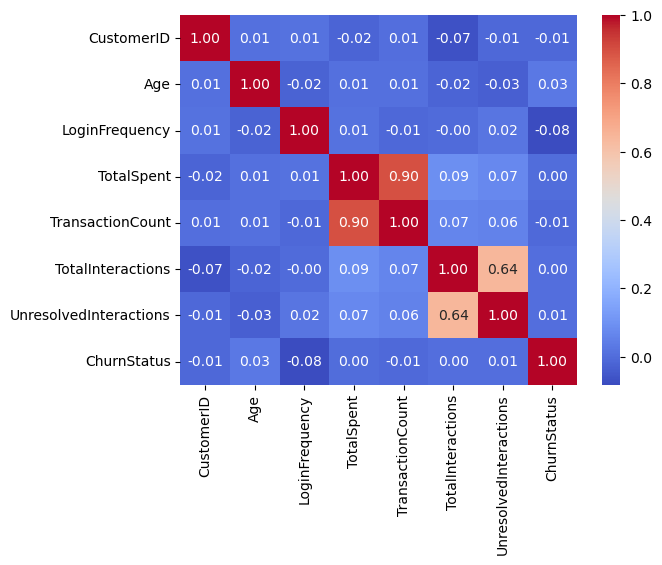

In [45]:
# .corr() calculates the Pearson correlation coefficient (-1 to 1)
corr_matrix = master_df[numeric_cols].corr()

# sns.heatmap creates a color-coded grid 
# Red usually means strong positive connection; Blue means strong negative connection
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

<Axes: xlabel='Gender', ylabel='count'>

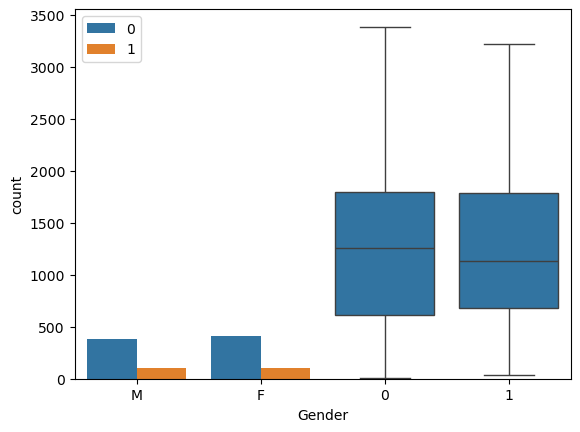

In [49]:
# sns.countplot: Shows the volume of people in categories (e.g., Male vs Female)
# hue='ChurnStatus': Splits the bars into "Stayed" vs "Churned" for comparison
sns.countplot(data=master_df, x='Gender', hue='ChurnStatus')

# sns.boxplot: Shows the range of numbers (Age, Spend)
# It helps identify if churned customers are typically younger or spend less.
sns.boxplot(data=master_df, x='ChurnStatus', y='TotalSpent')

In [50]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25) # The 25th percentile (bottom 25%)
    Q3 = df[column].quantile(0.75) # The 75th percentile (top 25%)
    IQR = Q3 - Q1                  # The middle 50% range
    # Anything 1.5x outside this middle range is considered a statistical outlier
    outliers = df[(df[column] < (Q1 - 1.5 * IQR)) | (df[column] > (Q3 + 1.5 * IQR))]
    return outliers

In [51]:
# .groupby('ChurnStatus').mean() shows the "Average Profile" of a loyal customer vs. a churned customer
churn_means = master_df.groupby('ChurnStatus')[numeric_cols].mean()

In [58]:
churn_means

,CustomerID,Age,LoginFrequency,TotalSpent,TransactionCount,TotalInteractions,UnresolvedInteractions,ChurnStatus
ChurnStatus,,,,,,,,
0,502.184673,43.040201,26.492462,1266.580038,5.065327,1.000000,0.477387,0.0
1,493.926471,44.151961,23.647059,1269.006078,5.009804,1.009804,0.485294,1.0
